    Traditional Method
        User
            Input
            Steps   =>  Program
        Machine Return  =>  Output

    Machine Learning
        User
            Input
            Output
        Machine
            Understand how input is converted to Output
            It will build its own logic

        Test
            input
            
            Expect Output

            Check is given output is correct or not
            we have to make some changes with respect to our input and output

In [1]:
def add(x,y):
    return x+y

add(4,5)

9

    Machine Learning
        Supervised
            Input   =>  Features
            Output  =>  Target
        Unsupervised
            Input   =>  Features
            Grouping    => Clustering
        Reinforcement
            Input
            Output
            Feedback

    Definition
    
    Machine Learning is a subset of Artificial Intelligence where computers learn patterns from data without being explicitly programmed for every scenario.
    
    Indian Analogy: The Chai Wala Example ☕
    
    Think of a chai wala near a railway station. 
    
    Initially, he doesn't know customer preferences. But over time:
        He notices office-goers prefer cutting chai (small, strong)
        College students want special chai with extra sugar
        Evening crowd prefers adrak chai

    Nobody taught him these rules explicitly — he learned from observing patterns. 
    This is exactly what ML does!

    The Three Types at a Glance


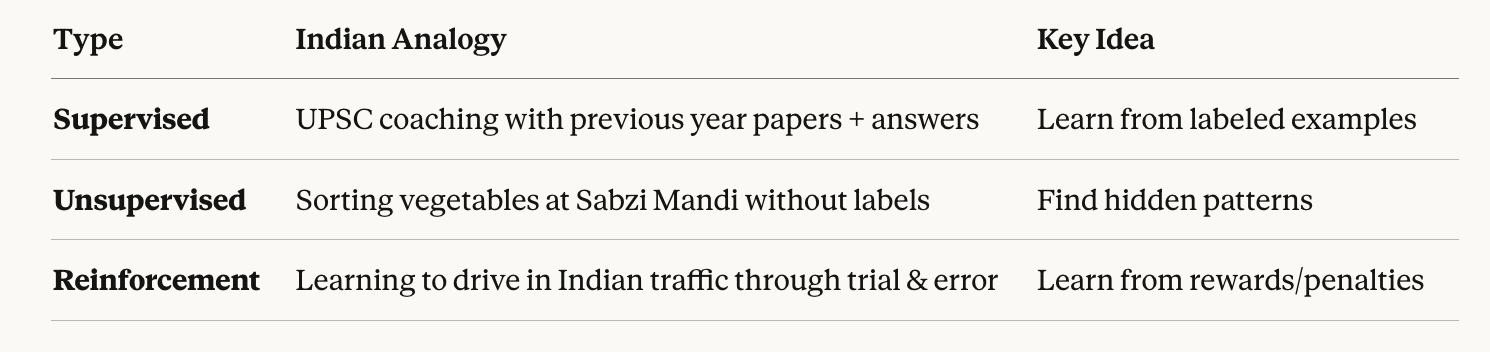

    SUPERVISED LEARNING

    Supervised Learning is like learning with a teacher who provides both questions AND answers. The algorithm learns the mapping between input (X) and output (Y).


    Indian Analogy: UPSC Preparation 📚
    Imagine preparing for UPSC:

    You have previous year questions (Input X)
    You have model answers (Output Y)
    You study the pattern of how questions map to answers
    When a new question comes, you can predict the answer

    This is supervised learning — learning from labeled examples!

    Algorithm 1: Linear Regression

    Definition

    Linear Regression finds a straight-line relationship between input variables (features) and a continuous output variable. It predicts numerical values.

    Indian Analogy: Predicting Mango Prices 🥭

    In Ratnagiri, mango farmers know:

    More rain → Higher yield → Lower price
    Less rain → Lower yield → Higher price
    Distance from mandi → Transportation cost → Higher price

    Linear Regression finds the exact mathematical relationship:

    Price = Base_Price + (a × Rainfall) + (b × Distance) + (c × Demand)

### Import Libraries

In [2]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [6]:
# Example: Predicting House Prices in Mumbai
data = {
    'area_sqft': [500, 750, 1000, 1200, 1500, 1800, 2000, 2500],
    'distance_from_station_km': [0.5, 1, 2, 1.5, 3, 2.5, 4, 5],
    'price_lakhs': [45, 62, 78, 85, 95, 105, 110, 125]
}
df = pd.DataFrame(data)

In [7]:
# Features (X) and Target (Y)
X = df[['area_sqft', 'distance_from_station_km']]
y = df['price_lakhs']

In [8]:
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
X_train

,area_sqft,distance_from_station_km
0,500,0.5
7,2500,5.0
2,1000,2.0
4,1500,3.0
3,1200,1.5
6,2000,4.0


In [10]:
X_test

,area_sqft,distance_from_station_km
1,750,1.0
5,1800,2.5


In [11]:
# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
# Predict
predictions = model.predict(X_test)

In [13]:
# Check coefficients
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")


Coefficients: [0.03759237 0.10250298]
Intercept: 34.8843861740167


In [20]:
# Predict for new house
new_house = [[1100, 2]]  # 1100 sqft, 2km from station
predicted_price = model.predict(new_house)
print(f"Predicted Price: ₹{predicted_price[0]:.2f} Lakhs")

Predicted Price: ₹76.44 Lakhs


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [15]:
from sklearn.metrics import r2_score

r2=r2_score(y_test,predictions)
print(f'R2 Score : {r2:.4f}')

R2 Score : 0.9933


In [16]:
# Predict for new house
new_house = [[700, 2]]  # 700 sqft, 2km from station
predicted_price = model.predict(new_house)
print(f"Predicted Price: ₹{predicted_price[0]:.2f} Lakhs")

Predicted Price: ₹61.40 Lakhs


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [17]:
from sklearn.metrics import r2_score

r2=r2_score(y_test,predictions)
print(f'R2 Score : {r2:.4f}')

R2 Score : 0.9933


    The model explains 99.33 % of variation in house prices

In [25]:
from sklearn.metrics import mean_absolute_error

mae=mean_absolute_error(y_test,predictions)
print(f"MAE: ₹{mae:.2f} Lakhs")

MAE: ₹1.69 Lakhs


    Your prediction is wrong by 1.69 Lakh

    3️⃣ Mean Squared Error (MSE) – Penalizes big mistakes

    What it means:
    Squares errors → big mistakes hurt more

In [26]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)
print(f"MSE: {mse:.2f}")

MSE: 3.10


In [27]:
rmse = np.sqrt(mse)
print(f"RMSE: ₹{rmse:.2f} Lakhs")


RMSE: ₹1.76 Lakhs


    The model explain 99.33 % of variance, with average prediction error of 1.69 or 1.76 Lakh

    R² → how well model explains price variation
    MAE → average mistake in ₹ Lakhs
    RMSE → penalises large errors (same unit as price)

In [28]:
results_df = pd.DataFrame({
    'Actual_Price_Lakhs': y_test.values,
    'Predicted_Price_Lakhs': predictions
})

results_df['Error_Lakhs'] = results_df['Actual_Price_Lakhs'] - results_df['Predicted_Price_Lakhs']

print(results_df)


   Actual_Price_Lakhs  Predicted_Price_Lakhs  Error_Lakhs
0                  62              63.181168    -1.181168
1                 105             102.806913     2.193087


In [29]:
df

,area_sqft,distance_from_station_km,price_lakhs
0,500,0.5,45
1,750,1.0,62
2,1000,2.0,78
3,1200,1.5,85
4,1500,3.0,95
5,1800,2.5,105
6,2000,4.0,110
7,2500,5.0,125


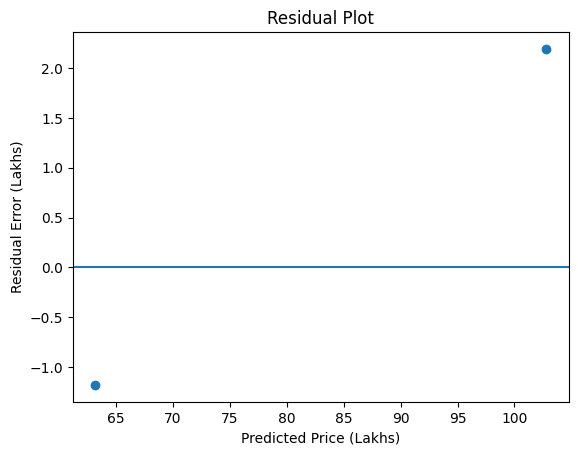

In [30]:
import matplotlib.pyplot as plt

plt.scatter(predictions, results_df['Error_Lakhs'])
plt.axhline(y=0)
plt.xlabel("Predicted Price (Lakhs)")
plt.ylabel("Residual Error (Lakhs)")
plt.title("Residual Plot")
plt.show()
